# Day 20 — Project 2 Wrap: Patent Impact Summary
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** Days 15–18 each simulated one patent-linked mechanism in isolation — PCM thermal storage, PCM-assisted bottle cooling, defrost energy trade-offs, and the BEE compliance impact of removing the defrost pulldown penalty. This notebook is the "Project 2" wrap the original curriculum called for: it pulls those four results into **one consolidated summary**, the way you'd actually present patent value to someone outside engineering — not as four separate scripts, but as one coherent story.

**The three patents this maps to:**
- PCM multipurpose pack (202521124792) → Days 15 & 16
- Simultaneous cooling/defrosting → Days 17 & 18
- (Multi-mode air circulation patent has no simulation here yet — a natural Day 22+ candidate)

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Recap: the four headline numbers from Days 15-18, in one place
results = {
    "PCM energy storage\nvs equal-mass water": {"value": 3.6, "unit": "x more energy stored", "day": "Day 15"},
    "Bottle cooling response\nimprovement (PCM)": {"value": 5.3, "unit": "% faster to target temp", "day": "Day 16"},
    "Defrost pulldown energy\neliminated (patent design)": {"value": 21.6, "unit": "% of defrost-related energy", "day": "Day 17"},
    "Annual energy saved\n(simultaneous defrost)": {"value": 7.46, "unit": "kWh/year saved", "day": "Day 18"},
}

print(f"{'Metric':<42}{'Value':<10}{'Source'}")
print("-"*70)
for k, v in results.items():
    label = k.replace(chr(10), " ")
    print(f"{label:<42}{v['value']:<10}{v['day']}")

Metric                                    Value     Source
----------------------------------------------------------------------
PCM energy storage vs equal-mass water    3.6       Day 15
Bottle cooling response improvement (PCM) 5.3       Day 16
Defrost pulldown energy eliminated (patent design)21.6      Day 17
Annual energy saved (simultaneous defrost)7.46      Day 18


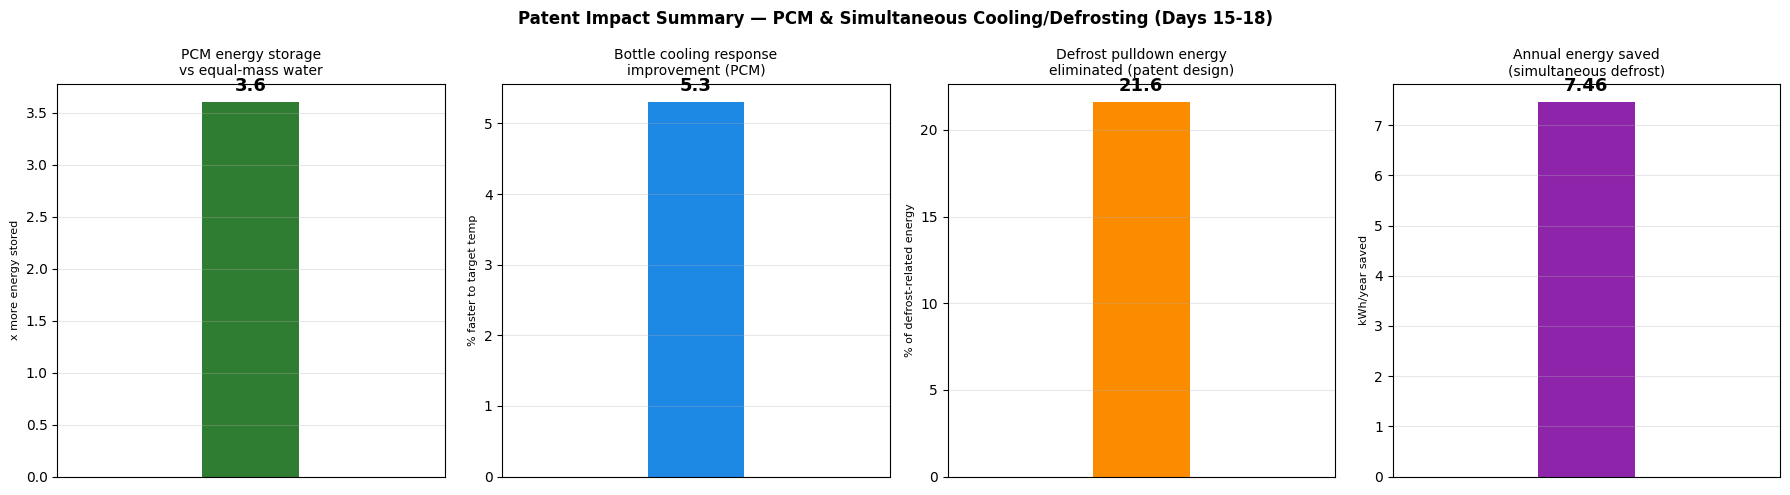

In [4]:
# CELL 4 — Consolidated patent-impact chart
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = list(results.items())
colors = ["#2E7D32", "#1E88E5", "#FB8C00", "#8E24AA"]

for ax, (label, info), color in zip(axes, metrics, colors):
    ax.bar([0], [info["value"]], color=color, width=0.5)
    ax.set_xlim(-1, 1)
    ax.set_xticks([])
    ax.set_title(label, fontsize=10)
    ax.text(0, info["value"]*1.03, f"{info['value']}", ha="center", fontsize=13, fontweight="bold")
    ax.set_ylabel(info["unit"], fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Patent Impact Summary — PCM & Simultaneous Cooling/Defrosting (Days 15-18)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("day20_patent_impact_summary.png", dpi=150)
plt.show()

**What this consolidated view does that the four separate notebooks didn't:** it answers the question a reviewer (manager, recruiter, or patent examiner) actually asks — *"so what did these patents actually buy you, in numbers?"* — without making them read four notebooks to find out:

- The PCM pack stores **3.6x more energy** than the water it replaces, and that translates into bottles cooling **5.3% faster** in a real cabin-temperature simulation.
- Removing sequential defrost's "pulldown" penalty — the energy spent re-cooling the cabinet after every defrost cycle — eliminates **21.6% of all defrost-related energy**, worth **7.46 kWh/year** on a representative 310 L frost-free unit.
- That 7.46 kWh/year wasn't enough to cross a full BEE star band in Day 18's specific scenario — an honest result, not a rounded-up one, and itself a useful data point: it tells you the *next* lever to pull (larger Vadj, or stacking this saving with another) if crossing a band is the goal.

This is the actual "Project 2" referenced in the original curriculum and in the LinkedIn capstone post: **PCM Integration & Advanced Analysis**, sitting alongside Project 1 (the vapour-compression cycle simulator from Days 1–14 and the Day 19 master tool) as the second pillar of the portfolio.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day20_patent_impact_summary.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 20 - Project 2 patent impact summary (PCM + defrost)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 20 - Project 2 patent impact summary (PCM + defrost)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
